## **DETEKSI FRAUD TRANSAKSI KARTU KREDIT MENGGUNAKAN DATASET IMBALANCED DENGAN NOICE TINGGI**

# 1. INSTALL & IMPORT LIBRARY

---




In [117]:
import pandas as pd

# 2. DATA UNDERSTANDING

# Load dataset




In [118]:
df = pd.read_csv('card_transdata_1.csv')
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1,1,0,0,0
1,10.829943,0.175592,1.294219,1,0,0,0,0
2,5.091079,0.805153,0.427715,1,0,0,1,0
3,2.247564,5.600044,0.362663,1,1,0,1,0
4,44.190936,0.566486,2.222767,1,1,0,1,0





# Tampilkan data



In [119]:
print("### 5 Data Teratas ###")
print(df.head())
print("\n" + "-"*50 + "\n")

### 5 Data Teratas ###
   distance_from_home  distance_from_last_transaction  \
0           57.877857                        0.311140   
1           10.829943                        0.175592   
2            5.091079                        0.805153   
3            2.247564                        5.600044   
4           44.190936                        0.566486   

   ratio_to_median_purchase_price  repeat_retailer  used_chip  \
0                        1.945940                1          1   
1                        1.294219                1          0   
2                        0.427715                1          0   
3                        0.362663                1          1   
4                        2.222767                1          1   

   used_pin_number  online_order  fraud  
0                0             0      0  
1                0             0      0  
2                0             1      0  
3                0             1      0  
4                0             1 

# Info dataset

In [120]:
print("### Informasi Dataset ###")
# Menampilkan jumlah baris, kolom, dan tipe data tiap fitur
print(df.info())
print("\n" + "-"*50 + "\n")

### Informasi Dataset ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   distance_from_home              19999 non-null  float64
 1   distance_from_last_transaction  19999 non-null  float64
 2   ratio_to_median_purchase_price  19999 non-null  float64
 3   repeat_retailer                 19999 non-null  int64  
 4   used_chip                       19999 non-null  int64  
 5   used_pin_number                 19999 non-null  int64  
 6   online_order                    19999 non-null  int64  
 7   fraud                           19999 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 1.2 MB
None

--------------------------------------------------



# Statistik deskriptif

In [121]:
print("### Statistik Deskriptif ###")
# Menampilkan mean, std, min, max, dan kuartil
print(df.describe())

### Statistik Deskriptif ###
       distance_from_home  distance_from_last_transaction  \
count        19999.000000                    19999.000000   
mean            27.448750                        5.013631   
std             65.541378                       24.328337   
min              0.046497                        0.000856   
25%              3.878712                        0.306488   
50%             10.186822                        1.024332   
75%             26.277094                        3.446000   
max           2353.226927                     1872.446884   

       ratio_to_median_purchase_price  repeat_retailer     used_chip  \
count                    19999.000000     19999.000000  19999.000000   
mean                         1.810665         0.882144      0.349517   
std                          2.630587         0.322445      0.476830   
min                          0.011373         0.000000      0.000000   
25%                          0.483907         1.000000      0

# Distribusi target


fraud
0    18284
1     1715
Name: count, dtype: int64


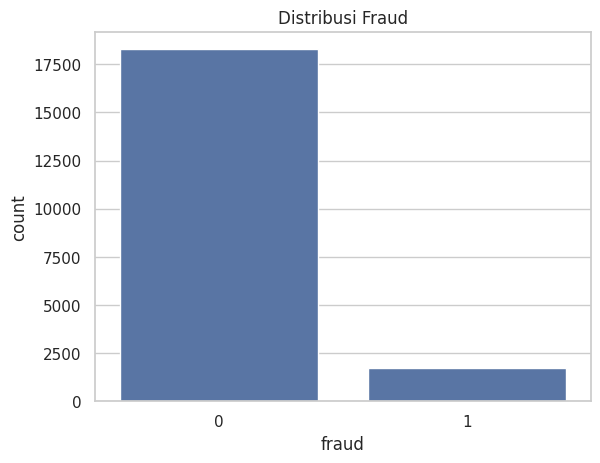

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df['fraud'].value_counts())

sns.countplot(x='fraud', data=df)
plt.title("Distribusi Fraud")
plt.show()

# 3. DATA PREPROCESSING



Inisialisasi dan Load Data

In [123]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Memuat dataset
# df = pd.read_csv('card_transdata_1.csv')

print("--- Data Berhasil Dimuat ---")
df.info()

--- Data Berhasil Dimuat ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   distance_from_home              19999 non-null  float64
 1   distance_from_last_transaction  19999 non-null  float64
 2   ratio_to_median_purchase_price  19999 non-null  float64
 3   repeat_retailer                 19999 non-null  int64  
 4   used_chip                       19999 non-null  int64  
 5   used_pin_number                 19999 non-null  int64  
 6   online_order                    19999 non-null  int64  
 7   fraud                           19999 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 1.2 MB


# Penanganan Missing Values


In [124]:
print("Jumlah Missing Values Sebelum:")
print(df.isnull().sum())

# Menghapus missing values
df = df.dropna()

print("\nJumlah Missing Values Setelah Drop:")
print(df.isnull().sum())

Jumlah Missing Values Sebelum:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

Jumlah Missing Values Setelah Drop:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64



# Penanganan Outlier (Clipping)



In [125]:
numeric_cols = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Clipping nilai outlier
    df[col] = np.where(df[col] > upper_bound, upper_bound,
              np.where(df[col] < lower_bound, lower_bound, df[col]))

print(f"Outlier pada {numeric_cols} telah ditangani dengan metode clipping.")
# Cek deskripsi statistik singkat
print(df[numeric_cols].describe())

Outlier pada ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price'] telah ditangani dengan metode clipping.
       distance_from_home  distance_from_last_transaction  \
count        19999.000000                    19999.000000   
mean            18.283964                        2.344067   
std             19.071429                        2.752201   
min              0.046497                        0.000856   
25%              3.878712                        0.306488   
50%             10.186822                        1.024332   
75%             26.277094                        3.446000   
max             59.874668                        8.155270   

       ratio_to_median_purchase_price  
count                    19999.000000  
mean                         1.497995  
std                          1.329313  
min                          0.011373  
25%                          0.483907  
50%                          1.010921  
75%                       

# Encoding Data

Tahap encoding tidak dilakukan karena seluruh fitur pada dataset sudah dalam bentuk numerik, baik kontinu maupun kategorikal biner.




In [126]:
print(df.dtypes)

distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                     int64
used_chip                           int64
used_pin_number                     int64
online_order                        int64
fraud                               int64
dtype: object


# Standarisasi Fitur

In [127]:
scaler = StandardScaler()

# Standarisasi hanya untuk fitur numerik kontinu
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Standarisasi selesai untuk fitur numerik.")

Standarisasi selesai untuk fitur numerik.


# Inspeksi Akhir

In [128]:
print("### 5 Data Teratas Setelah Preprocessing ###")
display(df.head())

print("\n### Cek Korelasi Singkat ###")
print(df.corr()['fraud'].sort_values(ascending=False))

### 5 Data Teratas Setelah Preprocessing ###


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,2.076136,-0.738674,0.336983,1,1,0,0,0
1,-0.390857,-0.787926,-0.153298,1,0,0,0,0
2,-0.691779,-0.559172,-0.805158,1,0,0,1,0
3,-0.840881,1.183074,-0.854096,1,1,0,1,0
4,1.358452,-0.645892,0.545237,1,1,0,1,0



### Cek Korelasi Singkat ###
fraud                             1.000000
ratio_to_median_purchase_price    0.470601
online_order                      0.202535
distance_from_home                0.127421
distance_from_last_transaction    0.044622
repeat_retailer                   0.003945
used_chip                        -0.069820
used_pin_number                  -0.099346
Name: fraud, dtype: float64


# 4. EDA (EXPLORATORY DATA ANALYSIS)

# distribusi data tiap fitur

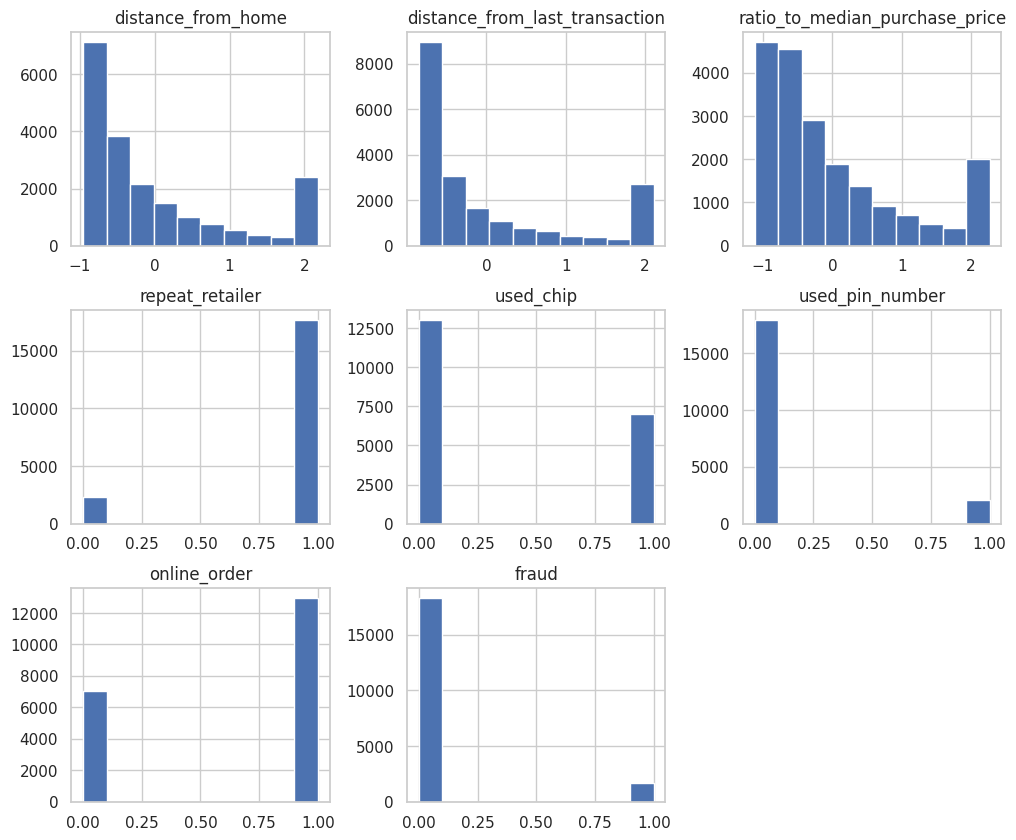

In [129]:
df.hist(figsize=(12,10))
plt.show()

# Pengaturan Global & Library

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur gaya visualisasi agar seragam
sns.set_theme(style="whitegrid")
print("Library visualisasi siap.")

Library visualisasi siap.


# Distribusi Target (Cek Imbalance)

/tmp/ipykernel_10961/1891102373.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fraud', data=df, palette='viridis')


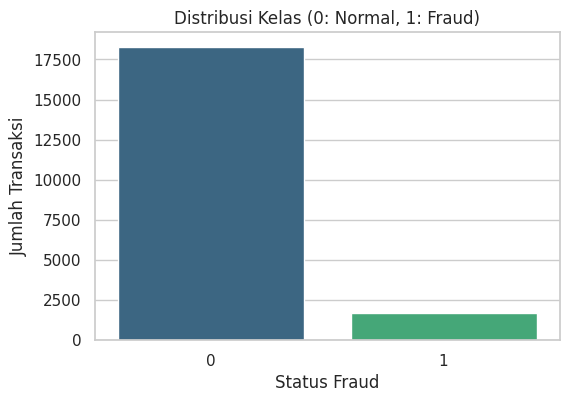

Persentase Target:
fraud
0    91.424571
1     8.575429
Name: proportion, dtype: float64


In [131]:
# A. Visualisasi Distribusi Target (Fraud vs Non-Fraud)
plt.figure(figsize=(6, 4))
sns.countplot(x='fraud', data=df, palette='viridis')
plt.title('Distribusi Kelas (0: Normal, 1: Fraud)')
plt.xlabel('Status Fraud')
plt.ylabel('Jumlah Transaksi')
plt.show()

# Menampilkan persentase agar lebih jelas
print("Persentase Target:")
print(df['fraud'].value_counts(normalize=True) * 100)

# Heatmap Korelasi

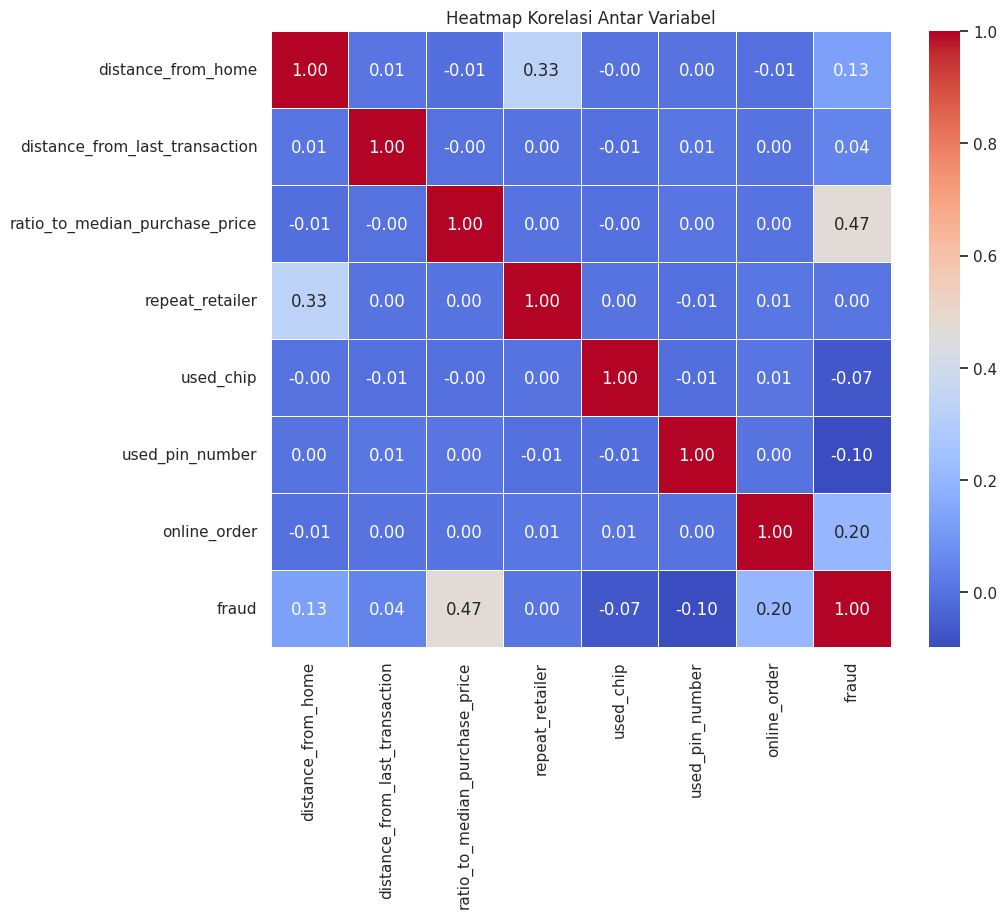

In [132]:
# B. Korelasi Antar Variabel (Heatmap)
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

# Boxplot Fitur Kontinu

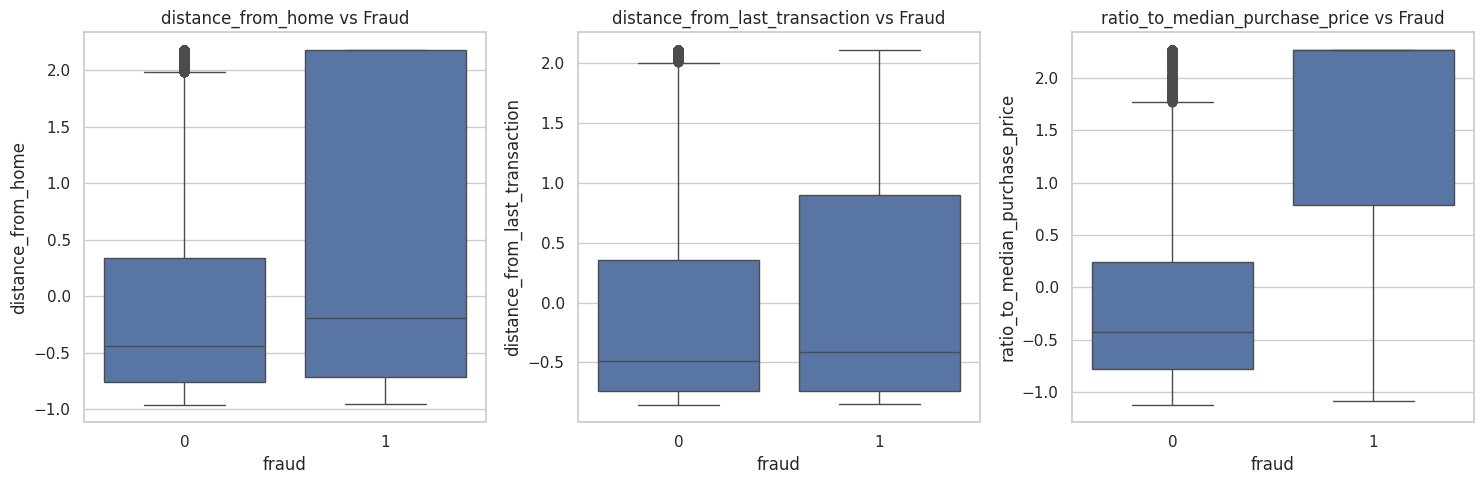

In [133]:
# C. Distribusi Fitur Kontinu terhadap Target
features = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='fraud', y=col, data=df)
    plt.title(f'{col} vs Fraud')

plt.tight_layout()
plt.show()

# Analisis Fitur Kategorikal (Online Order)

/tmp/ipykernel_10961/844239532.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='online_order', y='fraud', data=df, palette='magma')


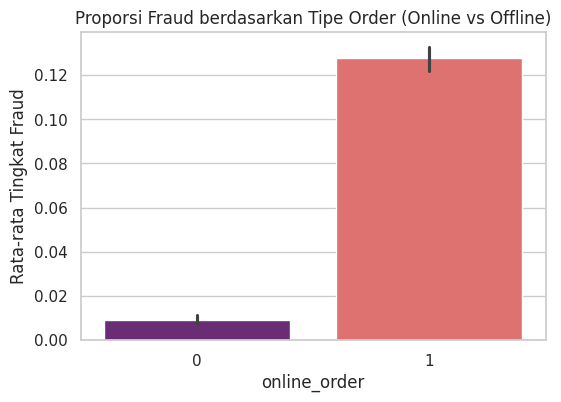

In [134]:
# D. Analisis Transaksi Online vs Fraud
plt.figure(figsize=(6, 4))
sns.barplot(x='online_order', y='fraud', data=df, palette='magma')
plt.title('Proporsi Fraud berdasarkan Tipe Order (Online vs Offline)')
plt.ylabel('Rata-rata Tingkat Fraud')
plt.show()

# Memisahkan fitur

In [135]:
from sklearn.model_selection import train_test_split

# Memisahkan fitur (X) dan target (y)
X = df.drop('fraud', axis=1)
y = df['fraud']

# 5. DATA SPLITTING (3 VARIASI)

In [136]:
# Variasi 1: 70% Training, 30% Testing (Umum digunakan)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.3, random_state=42)

In [137]:
# Variasi 2: 80% Training, 20% Testing (Standard industri untuk data besar)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

In [138]:
# Variasi 3: 90% Training, 10% Testing (Digunakan jika data sangat banyak)
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.1, random_state=42)

In [139]:
# Menampilkan hasil pembagian
print("### Hasil Pembagian Dataset ###")
print(f"Total Baris Dataset: {len(df)}")
print("-" * 30)
print(f"Variasi 1 (70/30) -> Train: {len(X_train1)}, Test: {len(X_test1)}")
print(f"Variasi 2 (80/20) -> Train: {len(X_train2)}, Test: {len(X_test2)}")
print(f"Variasi 3 (90/10) -> Train: {len(X_train3)}, Test: {len(X_test3)}")

### Hasil Pembagian Dataset ###
Total Baris Dataset: 19999
------------------------------
Variasi 1 (70/30) -> Train: 13999, Test: 6000
Variasi 2 (80/20) -> Train: 15999, Test: 4000
Variasi 3 (90/10) -> Train: 17999, Test: 2000


# 6. HANDLE IMBALANCED

In [140]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_smote, y_train_smote = ros.fit_resample(X_train2, y_train2)

print("Setelah Oversampling:")
print(pd.Series(y_train_smote).value_counts())


Setelah Oversampling:
fraud
0    14591
1    14591
Name: count, dtype: int64


# 7. MODEL BUILDING
# Logistic Regression


In [141]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg_compare = LogisticRegression(max_iter=1000, random_state=42)

data_splits = {
    '70:30': {'X_train': X_train1, 'X_test': X_test1, 'y_train': y_train1, 'y_test': y_test1},
    '80:20': {'X_train': X_train2, 'X_test': X_test2, 'y_train': y_train2, 'y_test': y_test2},
    '90:10': {'X_train': X_train3, 'X_test': X_test3, 'y_train': y_train3, 'y_test': y_test3}
}

comparison_results = {}

print("\n### Evaluasi Logistic Regression pada Berbagai Split Data ###")

for split_name, data in data_splits.items():
    print(f"\n--- Logistic Regression (Split {split_name}) ---")

    log_reg_compare.fit(data['X_train'], data['y_train'])
    y_pred = log_reg_compare.predict(data['X_test'])

    acc = accuracy_score(data['y_test'], y_pred)
    comparison_results[split_name] = acc

    print(f"Accuracy: {acc:.4f}")
    print(classification_report(data['y_test'], y_pred))

    # ✅ Tambahan confusion matrix
    cm = confusion_matrix(data['y_test'], y_pred)

    print("\nConfusion Matrix:")
    print("               Pred NORMAL | Pred FRAUD")
    print(f"Actual NORMAL     {cm[0,0]:5d}     |    {cm[0,1]:5d}")
    print(f"Actual FRAUD      {cm[1,0]:5d}     |    {cm[1,1]:5d}")

print("\n### Ringkasan Akurasi Logistic Regression pada Berbagai Split ###")
for split, acc in comparison_results.items():
    print(f"{split:<10}: {acc:.4f}")


### Evaluasi Logistic Regression pada Berbagai Split Data ###

--- Logistic Regression (Split 70:30) ---
Accuracy: 0.9562
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      5506
           1       0.77      0.66      0.71       494

    accuracy                           0.96      6000
   macro avg       0.87      0.82      0.84      6000
weighted avg       0.95      0.96      0.95      6000


Confusion Matrix:
               Pred NORMAL | Pred FRAUD
Actual NORMAL      5410     |       96
Actual FRAUD        167     |      327

--- Logistic Regression (Split 80:20) ---
Accuracy: 0.9550
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3693
           1       0.74      0.64      0.69       307

    accuracy                           0.95      4000
   macro avg       0.85      0.81      0.83      4000
weighted avg       0.95      0.95      0.95      4000


Confusion Matrix:
       

# Decision Tree

In [142]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dtree_compare = DecisionTreeClassifier(random_state=42)

data_splits = {
    '70:30': {'X_train': X_train1, 'X_test': X_test1, 'y_train': y_train1, 'y_test': y_test1},
    '80:20': {'X_train': X_train2, 'X_test': X_test2, 'y_train': y_train2, 'y_test': y_test2},
    '90:10': {'X_train': X_train3, 'X_test': X_test3, 'y_train': y_train3, 'y_test': y_test3}
}

comparison_results_dtree = {}

print("\n### Evaluasi Decision Tree pada Berbagai Split Data ###")

for split_name, data in data_splits.items():
    print(f"\n--- Decision Tree (Split {split_name}) ---")

    dtree_compare.fit(data['X_train'], data['y_train'])
    y_pred = dtree_compare.predict(data['X_test'])

    acc = accuracy_score(data['y_test'], y_pred)
    comparison_results_dtree[split_name] = acc

    print(f"Accuracy: {acc:.4f}")
    print(classification_report(data['y_test'], y_pred))

    # ✅ Tambahan confusion matrix
    cm = confusion_matrix(data['y_test'], y_pred)

    print("\nConfusion Matrix:")
    print("               Pred NORMAL | Pred FRAUD")
    print(f"Actual NORMAL     {cm[0,0]:5d}     |    {cm[0,1]:5d}")
    print(f"Actual FRAUD      {cm[1,0]:5d}     |    {cm[1,1]:5d}")



print("\n### Ringkasan Akurasi Decision Tree pada Berbagai Split ###")
for split, acc in comparison_results_dtree.items():
    print(f"{split:<10}: {acc:.4f}")


### Evaluasi Decision Tree pada Berbagai Split Data ###

--- Decision Tree (Split 70:30) ---
Accuracy: 0.9683
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      5506
           1       0.79      0.85      0.81       494

    accuracy                           0.97      6000
   macro avg       0.89      0.91      0.90      6000
weighted avg       0.97      0.97      0.97      6000


Confusion Matrix:
               Pred NORMAL | Pred FRAUD
Actual NORMAL      5392     |      114
Actual FRAUD         76     |      418

--- Decision Tree (Split 80:20) ---
Accuracy: 0.9728
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3693
           1       0.80      0.86      0.83       307

    accuracy                           0.97      4000
   macro avg       0.89      0.92      0.91      4000
weighted avg       0.97      0.97      0.97      4000


Confusion Matrix:
               Pred NORMA

# Random Forest (Ensemble Model)

In [143]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_compare = RandomForestClassifier(n_estimators=100, random_state=42)

data_splits = {
    '70:30': {'X_train': X_train1, 'X_test': X_test1, 'y_train': y_train1, 'y_test': y_test1},
    '80:20': {'X_train': X_train2, 'X_test': X_test2, 'y_train': y_train2, 'y_test': y_test2},
    '90:10': {'X_train': X_train3, 'X_test': X_test3, 'y_train': y_train3, 'y_test': y_test3}
}

comparison_results_rf = {}

print("\n### Evaluasi Random Forest pada Berbagai Split Data ###")

for split_name, data in data_splits.items():
    print(f"\n--- Random Forest (Split {split_name}) ---")

    rf_compare.fit(data['X_train'], data['y_train'])
    y_pred = rf_compare.predict(data['X_test'])

    acc = accuracy_score(data['y_test'], y_pred)
    comparison_results_rf[split_name] = acc

    print(f"Accuracy: {acc:.4f}")
    print(classification_report(data['y_test'], y_pred))

    # ✅ Tambahan confusion matrix
    cm = confusion_matrix(data['y_test'], y_pred)

    print("\nConfusion Matrix:")
    print("               Pred NORMAL | Pred FRAUD")
    print(f"Actual NORMAL     {cm[0,0]:5d}     |    {cm[0,1]:5d}")
    print(f"Actual FRAUD      {cm[1,0]:5d}     |    {cm[1,1]:5d}")



print("\n### Ringkasan Akurasi Random Forest pada Berbagai Split ###")
for split, acc in comparison_results_rf.items():
    print(f"{split:<10}: {acc:.4f}")


### Evaluasi Random Forest pada Berbagai Split Data ###

--- Random Forest (Split 70:30) ---
Accuracy: 0.9762
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5506
           1       0.85      0.86      0.86       494

    accuracy                           0.98      6000
   macro avg       0.92      0.92      0.92      6000
weighted avg       0.98      0.98      0.98      6000


Confusion Matrix:
               Pred NORMAL | Pred FRAUD
Actual NORMAL      5432     |       74
Actual FRAUD         69     |      425

--- Random Forest (Split 80:20) ---
Accuracy: 0.9788
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3693
           1       0.86      0.86      0.86       307

    accuracy                           0.98      4000
   macro avg       0.92      0.93      0.93      4000
weighted avg       0.98      0.98      0.98      4000


Confusion Matrix:
               Pred NORMA

### Tabel Perbandingan Akurasi Antar Model dan Split Data

In [144]:
import pandas as pd

# Mengumpulkan hasil dari setiap model
comparison_table = {
    'Logistic Regression': comparison_results,
    'Decision Tree': comparison_results_dtree,
    'Random Forest': comparison_results_rf
}

# Membuat DataFrame dari dictionary hasil
df_comparison = pd.DataFrame(comparison_table)

print("### Tabel Perbandingan Akurasi Berdasarkan Model dan Split Data ###")
display(df_comparison.round(4))

# Menemukan model terbaik dan split terbaik
best_accuracy = 0
best_model_overall = ''
best_split_overall = ''

for model_name, results_dict in comparison_table.items():
    for split_name, accuracy in results_dict.items():
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model_overall = model_name
            best_split_overall = split_name

print(f"\nModel Terbaik Keseluruhan: {best_model_overall} dengan akurasi {best_accuracy:.4f} pada split {best_split_overall}")

### Tabel Perbandingan Akurasi Berdasarkan Model dan Split Data ###


,Logistic Regression,Decision Tree,Random Forest
70:30,0.9562,0.9683,0.9762
80:20,0.9550,0.9728,0.9788
90:10,0.9505,0.9725,0.9750



Model Terbaik Keseluruhan: Random Forest dengan akurasi 0.9788 pada split 80:20


# 8. Hyperparameter Tuning (Randomized Search)

In [145]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Ambil sampel (agar proses tuning tidak memakan waktu berjam-jam)
X_sample = X_train2.sample(n=min(50000, len(X_train2)), random_state=42)
y_sample = y_train2.loc[X_sample.index]

# Definisi ruang pencarian parameter
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5],
    'bootstrap': [True]
}

rf_base = RandomForestClassifier(random_state=42)

# Gunakan scoring='f1' karena sangat penting untuk mendeteksi fraud dengan akurat
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    scoring='f1'
)

print(f"--- Memulai Tuning pada {len(X_sample)} data sampel ---")
random_search.fit(X_sample, y_sample)

print("\n--- Hasil Tuning ---")
print("Parameter Terbaik:", random_search.best_params_)
print(f"Best F1-Score: {random_search.best_score_:.4f}")

--- Memulai Tuning pada 15999 data sampel ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits

--- Hasil Tuning ---
Parameter Terbaik: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 12, 'bootstrap': True}
Best F1-Score: 0.8354


# 9. MODEL EVALUATION

In [146]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate(y_test, y_pred, name):
    print(f"\n===== {name} === ")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

y_pred_log = log_reg_compare.predict(X_test2)
y_pred_dtree = dtree_compare.predict(X_test2)
y_pred_rf = rf_compare.predict(X_test2)
y_pred_best = random_search.best_estimator_.predict(X_test2)

evaluate(y_test2, y_pred_log, "Logistic Regression")
evaluate(y_test2, y_pred_dtree, "Decision Tree")
evaluate(y_test2, y_pred_rf, "Random Forest")


===== Logistic Regression === 
Accuracy: 0.9555
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3693
           1       0.74      0.65      0.69       307

    accuracy                           0.96      4000
   macro avg       0.86      0.81      0.83      4000
weighted avg       0.95      0.96      0.95      4000

Confusion Matrix:
 [[3623   70]
 [ 108  199]]

===== Decision Tree === 
Accuracy: 0.98625
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3693
           1       0.90      0.92      0.91       307

    accuracy                           0.99      4000
   macro avg       0.95      0.96      0.95      4000
weighted avg       0.99      0.99      0.99      4000

Confusion Matrix:
 [[3663   30]
 [  25  282]]

===== Random Forest === 
Accuracy: 0.9875
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3693
         

# Pelatihan Model Final (Optimized Model)

In [147]:
from sklearn.metrics import classification_report

# Coba gunakan parameter yang lebih "ketat" untuk mencegah overfitting
rf_optimized = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,            # Membatasi kedalaman agar tidak 'overfit' (menghafal data)
    min_samples_leaf=5,       # Menghindari node yang terlalu spesifik
    random_state=42,
    n_jobs=-1                 # Menggunakan semua core CPU agar lebih cepat
)

print("--- Melatih Model Teroptimasi pada Seluruh Data Training ---")
rf_optimized.fit(X_train2, y_train2)

# Evaluasi hasil
train_acc = rf_optimized.score(X_train2, y_train2)
test_acc = rf_optimized.score(X_test2, y_test2)

print(f"Training Accuracy : {train_acc:.4f}")
print(f"Testing Accuracy  : {test_acc:.4f}")

--- Melatih Model Teroptimasi pada Seluruh Data Training ---
Training Accuracy : 0.9829
Testing Accuracy  : 0.9798


# Analisis Detail Model Teroptimasi

### Laporan Klasifikasi Akhir (Model Teroptimasi) ###
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3693
           1       0.90      0.83      0.86       307

    accuracy                           0.98      4000
   macro avg       0.94      0.91      0.93      4000
weighted avg       0.98      0.98      0.98      4000



<Axes: title={'center': 'Fitur Paling Berpengaruh dalam Deteksi Fraud'}>

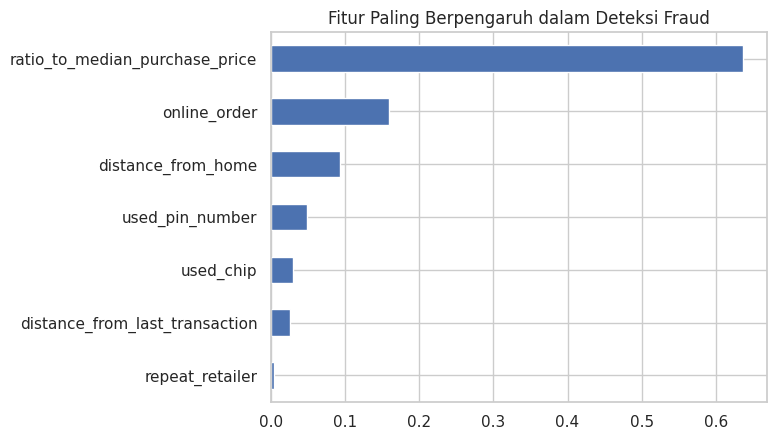

In [148]:
# Prediksi data test
y_pred_final = rf_optimized.predict(X_test2)

print("### Laporan Klasifikasi Akhir (Model Teroptimasi) ###")
print(classification_report(y_test2, y_pred_final))

# Opsional: Cek fitur apa yang paling berpengaruh menurut model ini
importances = pd.Series(rf_optimized.feature_importances_, index=X_train2.columns)
importances.sort_values().plot(kind='barh', title='Fitur Paling Berpengaruh dalam Deteksi Fraud')

# 10. MODEL COMPARISON

### Ringkasan Akurasi Model ###
                 Model  Accuracy
0  Logistic Regression   0.95550
1        Decision Tree   0.98625
2        Random Forest   0.98750


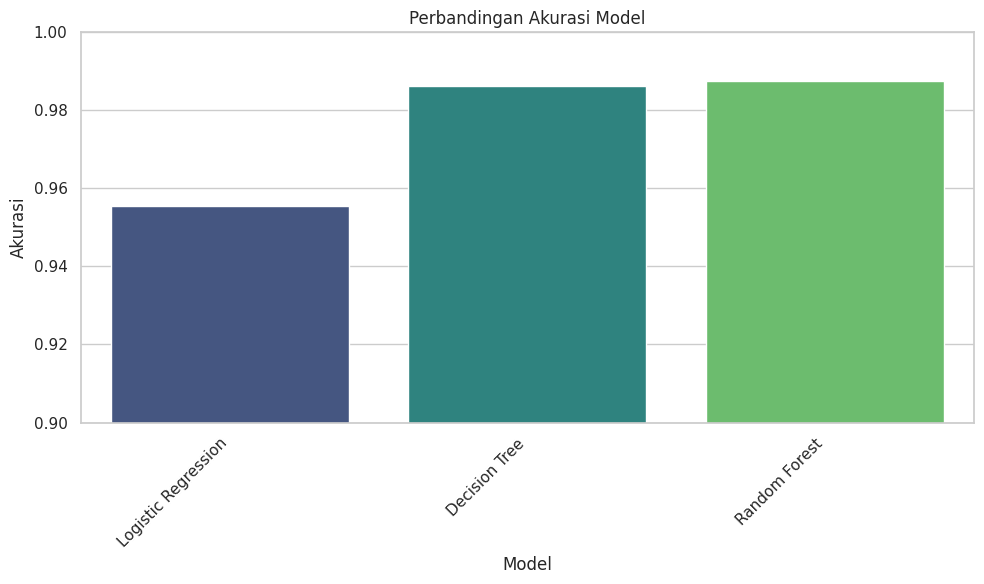

In [149]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test2, y_pred_log),
        accuracy_score(y_test2, y_pred_dtree),
        accuracy_score(y_test2, y_pred_rf)
    ]
})

print("### Ringkasan Akurasi Model ###")
print(results_df)

# Grafik
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title("Perbandingan Akurasi Model")
plt.xlabel("Model")
plt.ylabel("Akurasi")
plt.ylim(0.9, 1.0) # Fokus pada rentang akurasi yang relevan
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Tabel Recall Berdasarkan Model dan Split Data ###


,Split,Model,Recall
0,70:30,Logistic Regression,0.6619
1,70:30,Decision Tree,0.8462
2,70:30,Random Forest,0.8603
3,80:20,Logistic Regression,0.6450
4,80:20,Decision Tree,0.8599
5,80:20,Random Forest,0.8632
6,90:10,Logistic Regression,0.6194
7,90:10,Decision Tree,0.8387
8,90:10,Random Forest,0.8387


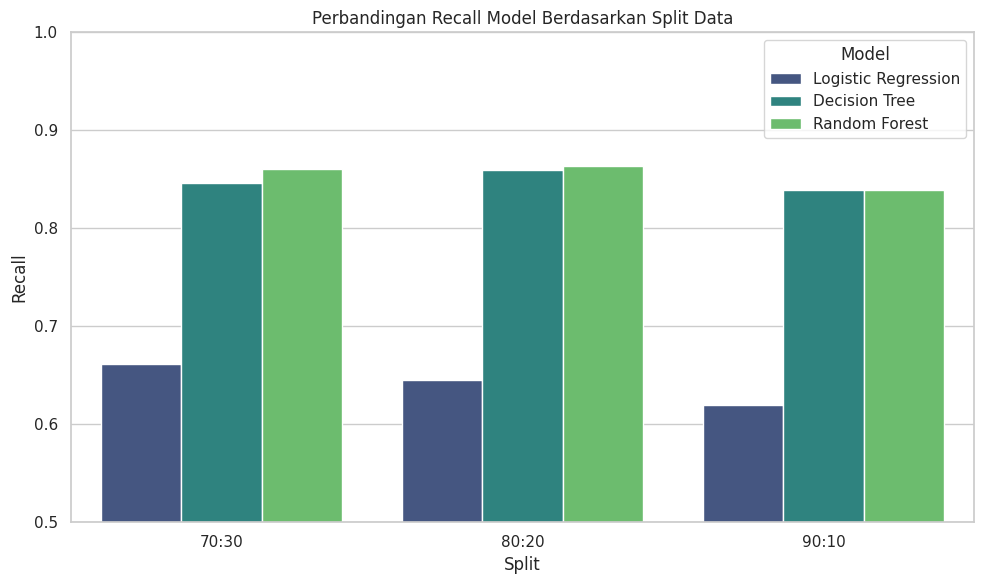

In [150]:
import pandas as pd
from sklearn.metrics import classification_report

# Ubah results ke format tabel
rows = []

# Dictionaries to hold recall scores for each model across different splits
recall_results = {
    'Logistic Regression': {},
    'Decision Tree': {},
    'Random Forest': {}
}

# Re-evaluate models to get recall for each split
for split_name, data in data_splits.items():
    # Logistic Regression
    log_reg_compare.fit(data['X_train'], data['y_train'])
    y_pred_log = log_reg_compare.predict(data['X_test'])
    report_log = classification_report(data['y_test'], y_pred_log, output_dict=True)
    recall_results['Logistic Regression'][split_name] = report_log['1']['recall'] # Get recall for class 1 (fraud)

    # Decision Tree
    dtree_compare.fit(data['X_train'], data['y_train'])
    y_pred_dtree = dtree_compare.predict(data['X_test'])
    report_dtree = classification_report(data['y_test'], y_pred_dtree, output_dict=True)
    recall_results['Decision Tree'][split_name] = report_dtree['1']['recall'] # Get recall for class 1 (fraud)

    # Random Forest
    rf_compare.fit(data['X_train'], data['y_train'])
    y_pred_rf = rf_compare.predict(data['X_test'])
    report_rf = classification_report(data['y_test'], y_pred_rf, output_dict=True)
    recall_results['Random Forest'][split_name] = report_rf['1']['recall'] # Get recall for class 1 (fraud)

# Populate rows for DataFrame
for split_name in data_splits.keys():
    rows.append([split_name, 'Logistic Regression', recall_results['Logistic Regression'][split_name]])
    rows.append([split_name, 'Decision Tree', recall_results['Decision Tree'][split_name]])
    rows.append([split_name, 'Random Forest', recall_results['Random Forest'][split_name]])

df_plot = pd.DataFrame(rows, columns=['Split', 'Model', 'Recall'])

print("### Tabel Recall Berdasarkan Model dan Split Data ###")
display(df_plot.round(4))

# Opsional: Plotting the recall values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Split', y='Recall', hue='Model', data=df_plot, palette='viridis')
plt.title('Perbandingan Recall Model Berdasarkan Split Data')
plt.ylabel('Recall')
plt.ylim(0.5, 1.0) # Adjust y-axis to focus on relevant recall range
plt.tight_layout()
plt.show()

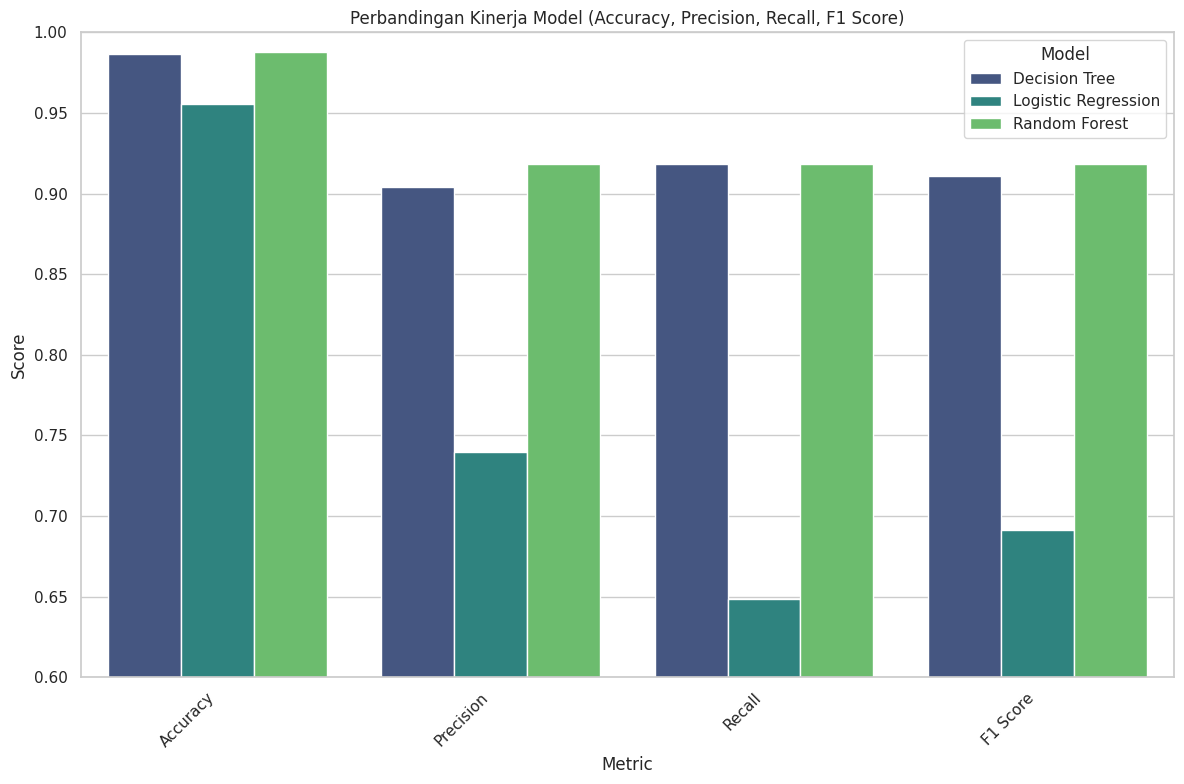

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mempersiapkan data untuk plot
df_plot_melted = df_avg.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 8))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_plot_melted, palette='viridis')
plt.title('Perbandingan Kinerja Model (Accuracy, Precision, Recall, F1 Score)')
plt.ylabel('Score')
plt.ylim(0.6, 1.0) # Fokus pada rentang skor yang relevan
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

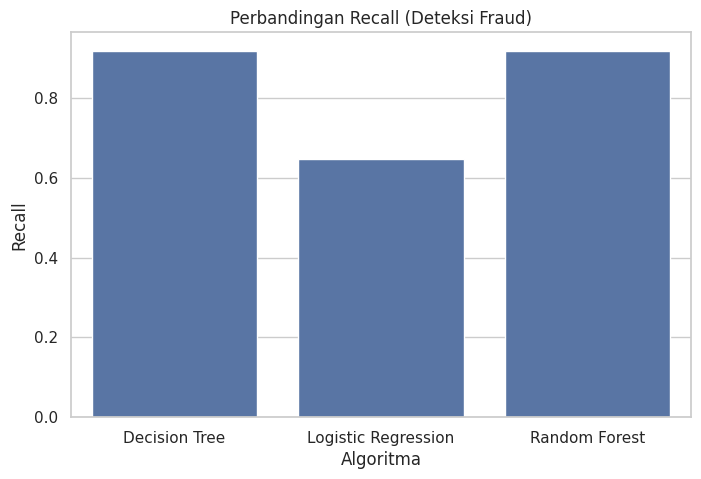

In [152]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_avg,
    x='Model',
    y='Recall'
)

plt.title('Perbandingan Recall (Deteksi Fraud)')
plt.ylabel('Recall')
plt.xlabel('Algoritma')

plt.show()

In [153]:
# Re-fit the models with the 80:20 training data to ensure consistency
log_reg_compare.fit(X_train2, y_train2)
dtree_compare.fit(X_train2, y_train2)
rf_compare.fit(X_train2, y_train2)

# Make predictions using the re-fitted models on the 80:20 test data
y_pred_log_80_20 = log_reg_compare.predict(X_test2)
y_pred_dtree_80_20 = dtree_compare.predict(X_test2)
y_pred_rf_80_20 = rf_compare.predict(X_test2)

results = {
    "Logistic Regression": accuracy_score(y_test2, y_pred_log_80_20),
    "Decision Tree": accuracy_score(y_test2, y_pred_dtree_80_20),
    "Random Forest": accuracy_score(y_test2, y_pred_rf_80_20)
}

best_model_name = max(results, key=results.get)
print("Model Terbaik:", best_model_name)

Model Terbaik: Random Forest


In [154]:
df['fraud'].nunique()

2

In [155]:
import joblib

# simpan model
joblib.dump(rf_optimized, "model_fraud.pkl")

# simpan scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [156]:
import joblib

joblib.dump(rf_optimized, 'best_model.pkl')
print("Model berhasil disimpan!")

Model berhasil disimpan!


In [157]:
from google.colab import files

files.download('best_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [158]:
joblib.dump(scaler, 'scaler.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

UJI COBA DATA BARU


In [159]:
import numpy as np

data_baru = np.array([[120.5, 15.2, 3.8, 1, 0, 0, 1]])

In [160]:
numeric = data_baru[:, :3]
non_numeric = data_baru[:, 3:]

In [161]:
numeric_scaled = scaler.transform(numeric)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [162]:
data_final = np.hstack((numeric_scaled, non_numeric))

In [163]:
data_final_df = pd.DataFrame(data_final, columns=X_train2.columns)
pred = rf_optimized.predict(data_final_df)[0]

In [164]:
pred = rf_optimized.predict(data_final_df)[0]

print("Hasil Prediksi (Class):", pred)

if pred == 0:
    print("Keterangan: NORMAL")
else:
    print("Keterangan: FRAUD")

Hasil Prediksi (Class): 1
Keterangan: FRAUD
